In [1]:
# This notebook takes the input dataset, finds quartiles for the medical interventions (IV in, max vaso in)
# for each block.
# We then discretise actions in the original dataset according to what bin they fall in, and then save 
# a new dataframe with the discretised actions.

In [2]:
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from pandas import DataFrame

In [5]:
orig_data = pd.read_csv("/home/yusuf/Yusuf/Kuliah/AI/Project/ICU/JC-Reproduce/data/raw/MKdataset07Feb17.csv")

In [6]:
orig_data.head()

,bloc,icustayid,charttime,gender,age,elixhauser,re_admission,died_in_hosp,died_within_48h_of_out_time,mortality_90d,...,PaO2_FiO2,median_dose_vaso,max_dose_vaso,input_total,input_4hourly,output_total,output_4hourly,cumulated_balance,SOFA,SIRS
0,1,3,7245486000,0,17639.826435,0,0,0,0,1,...,168.0,0.0,0.0,6527.0,50.0,13617.0,520.0,-7090.0,8,2
1,2,3,7245500400,0,17639.826435,0,0,0,0,1,...,84.0,0.0,0.0,6577.0,50.0,13982.0,365.0,-7405.0,7,2
2,3,3,7245514800,0,17639.826435,0,0,0,0,1,...,144.0,0.0,0.0,6627.0,50.0,14262.0,280.0,-7635.0,6,2
3,4,3,7245529200,0,17639.826435,0,0,0,0,1,...,144.0,0.0,0.0,6677.0,50.0,14602.0,340.0,-7925.0,6,1
4,5,3,7245543600,0,17639.826435,0,0,0,0,1,...,144.0,0.0,0.0,6727.0,50.0,15142.0,540.0,-8415.0,6,2


In [9]:
# assume we're using input_4hourly and max_dose_vaso as the input params for now
interventions = orig_data[["max_dose_vaso", "input_4hourly"]]

In [10]:
interventions.head()

,max_dose_vaso,input_4hourly
0,0.0,50.0
1,0.0,50.0
2,0.0,50.0
3,0.0,50.0
4,0.0,50.0


In [11]:
adjusted_vaso = interventions["max_dose_vaso"][interventions["max_dose_vaso"] >0]
adjusted_iv = interventions["input_4hourly"][interventions["input_4hourly"]>0]

In [12]:
vaso_quartiles = adjusted_vaso.quantile([0.25,0.50,0.75])
iv_quartiles = adjusted_iv.quantile([0.25,0.5,0.75])

In [13]:
vq = np.array(vaso_quartiles)
vq

array([0.08, 0.2 , 0.45])

In [14]:
ivq = np.array(iv_quartiles)
ivq

array([ 48.87666667, 150.        , 500.        ])

In [17]:
import copy
discretised_int = copy.deepcopy(interventions)

In [18]:
discretised_int['vaso_input'] = discretised_int['max_dose_vaso']
discretised_int['vaso_input'][interventions['max_dose_vaso'] == 0.0] = 0
discretised_int['vaso_input'][(interventions['max_dose_vaso'] > 0.0) & (interventions['max_dose_vaso'] < vq[0])] = 1
discretised_int['vaso_input'][(interventions['max_dose_vaso'] >= vq[0]) & (interventions['max_dose_vaso'] < vq[1])] = 2
discretised_int['vaso_input'][(interventions['max_dose_vaso'] >= vq[1]) & (interventions['max_dose_vaso'] < vq[2])] = 3
a = interventions['max_dose_vaso'] >= vq[2]
discretised_int['vaso_input'][a] = 4

In [19]:
discretised_int['iv_input'] = discretised_int['input_4hourly']
discretised_int['iv_input'][interventions['input_4hourly'] == 0.0] = 0
discretised_int['iv_input'][(interventions['input_4hourly'] > 0.0) & (interventions['input_4hourly'] < ivq[0])] = 1
discretised_int['iv_input'][(interventions['input_4hourly'] >=  ivq[0]) & (interventions['input_4hourly'] <  ivq[1])] = 2
discretised_int['iv_input'][(interventions['input_4hourly'] >=  ivq[1]) & (interventions['input_4hourly'] < ivq[2])] = 3
discretised_int['iv_input'][(interventions['input_4hourly'] >=  ivq[2])] = 4

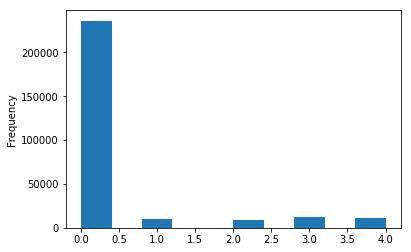

In [20]:
discretised_int['vaso_input'].plot.hist()

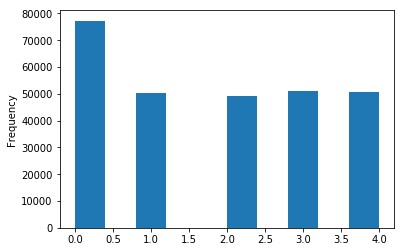

In [21]:
discretised_int['iv_input'].plot.hist()

In [22]:
disc_inp_data = copy.deepcopy(orig_data)

In [23]:
disc_inp_data['vaso_input'] = discretised_int['vaso_input']
disc_inp_data['iv_input'] = discretised_int['iv_input']

In [24]:
disc_inp_data.head()

,bloc,icustayid,charttime,gender,age,elixhauser,re_admission,died_in_hosp,died_within_48h_of_out_time,mortality_90d,...,max_dose_vaso,input_total,input_4hourly,output_total,output_4hourly,cumulated_balance,SOFA,SIRS,vaso_input,iv_input
0,1,3,7245486000,0,17639.826435,0,0,0,0,1,...,0.0,6527.0,50.0,13617.0,520.0,-7090.0,8,2,0.0,2.0
1,2,3,7245500400,0,17639.826435,0,0,0,0,1,...,0.0,6577.0,50.0,13982.0,365.0,-7405.0,7,2,0.0,2.0
2,3,3,7245514800,0,17639.826435,0,0,0,0,1,...,0.0,6627.0,50.0,14262.0,280.0,-7635.0,6,2,0.0,2.0
3,4,3,7245529200,0,17639.826435,0,0,0,0,1,...,0.0,6677.0,50.0,14602.0,340.0,-7925.0,6,1,0.0,2.0
4,5,3,7245543600,0,17639.826435,0,0,0,0,1,...,0.0,6727.0,50.0,15142.0,540.0,-8415.0,6,2,0.0,2.0


In [25]:
disc_inp_data['vaso_input'].value_counts()

0.0    236039
3.0     11883
4.0     11103
1.0     10302
2.0      9288
Name: vaso_input, dtype: int64

In [26]:
disc_inp_data['iv_input'].value_counts()

0.0    77294
3.0    51064
4.0    50710
1.0    50330
2.0    49217
Name: iv_input, dtype: int64

In [27]:
disc_inp_data.to_csv('/home/yusuf/Yusuf/Kuliah/AI/Project/ICU/JC-Reproduce/data/processed/discretised_input_data.csv', index=False)